In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, AffinityPropagation, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

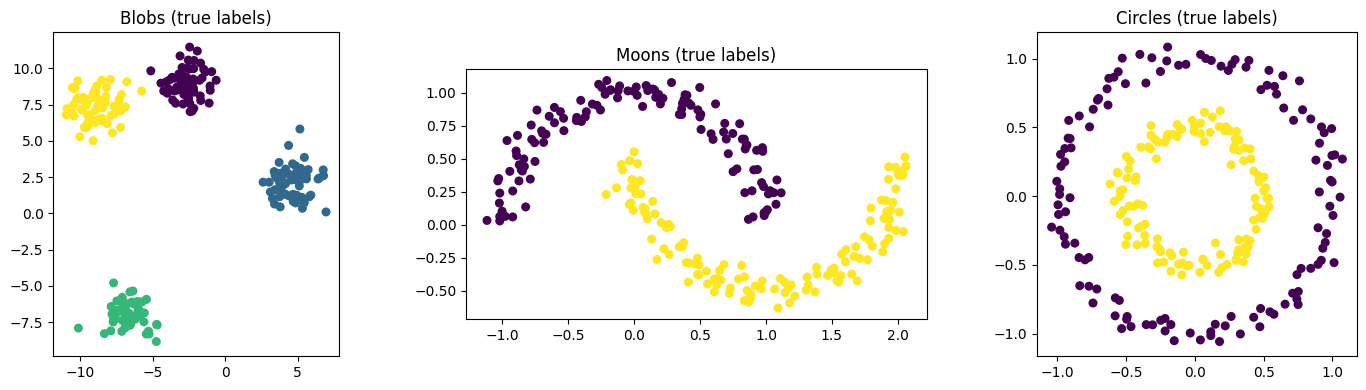

In [2]:
datasets = {
    "Blobs": make_blobs(n_samples=250, centers=4, random_state=42),
    "Moons": make_moons(n_samples=250, noise=0.07, random_state=42),
    "Circles": make_circles(n_samples=250, factor=0.5, noise=0.05, random_state=42)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (X, y)) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=30)
    ax.set_title(f"{name} (true labels)")
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

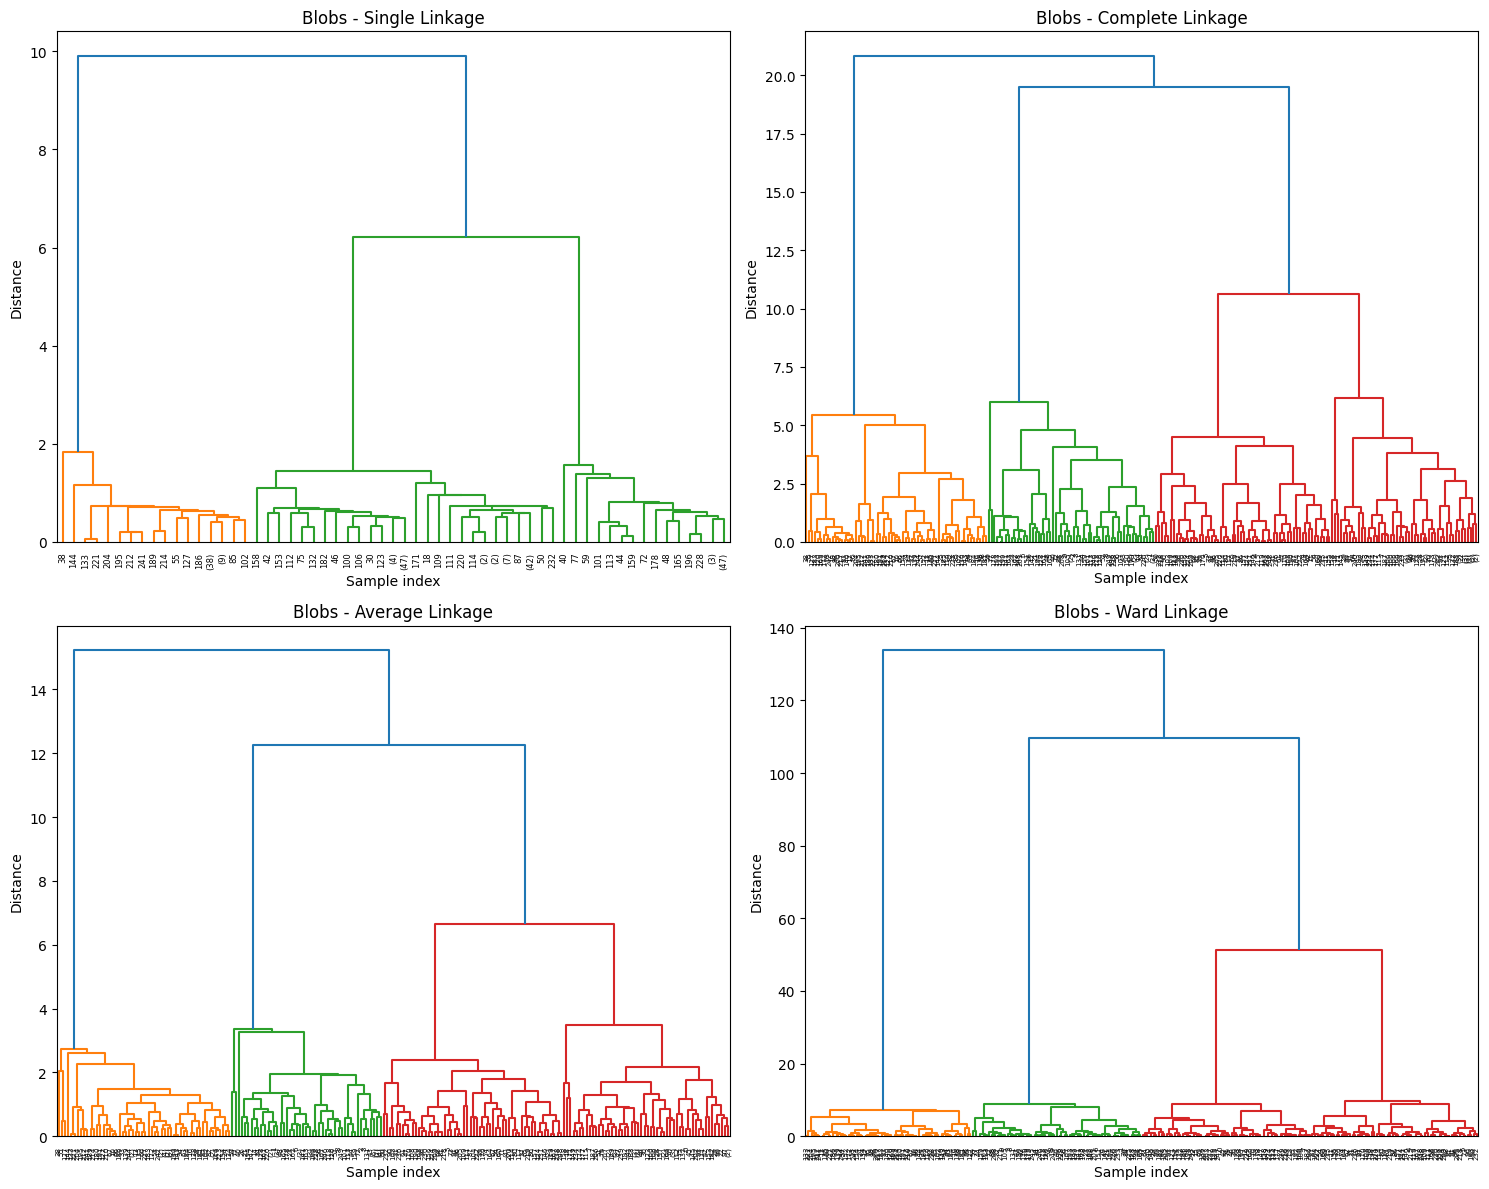

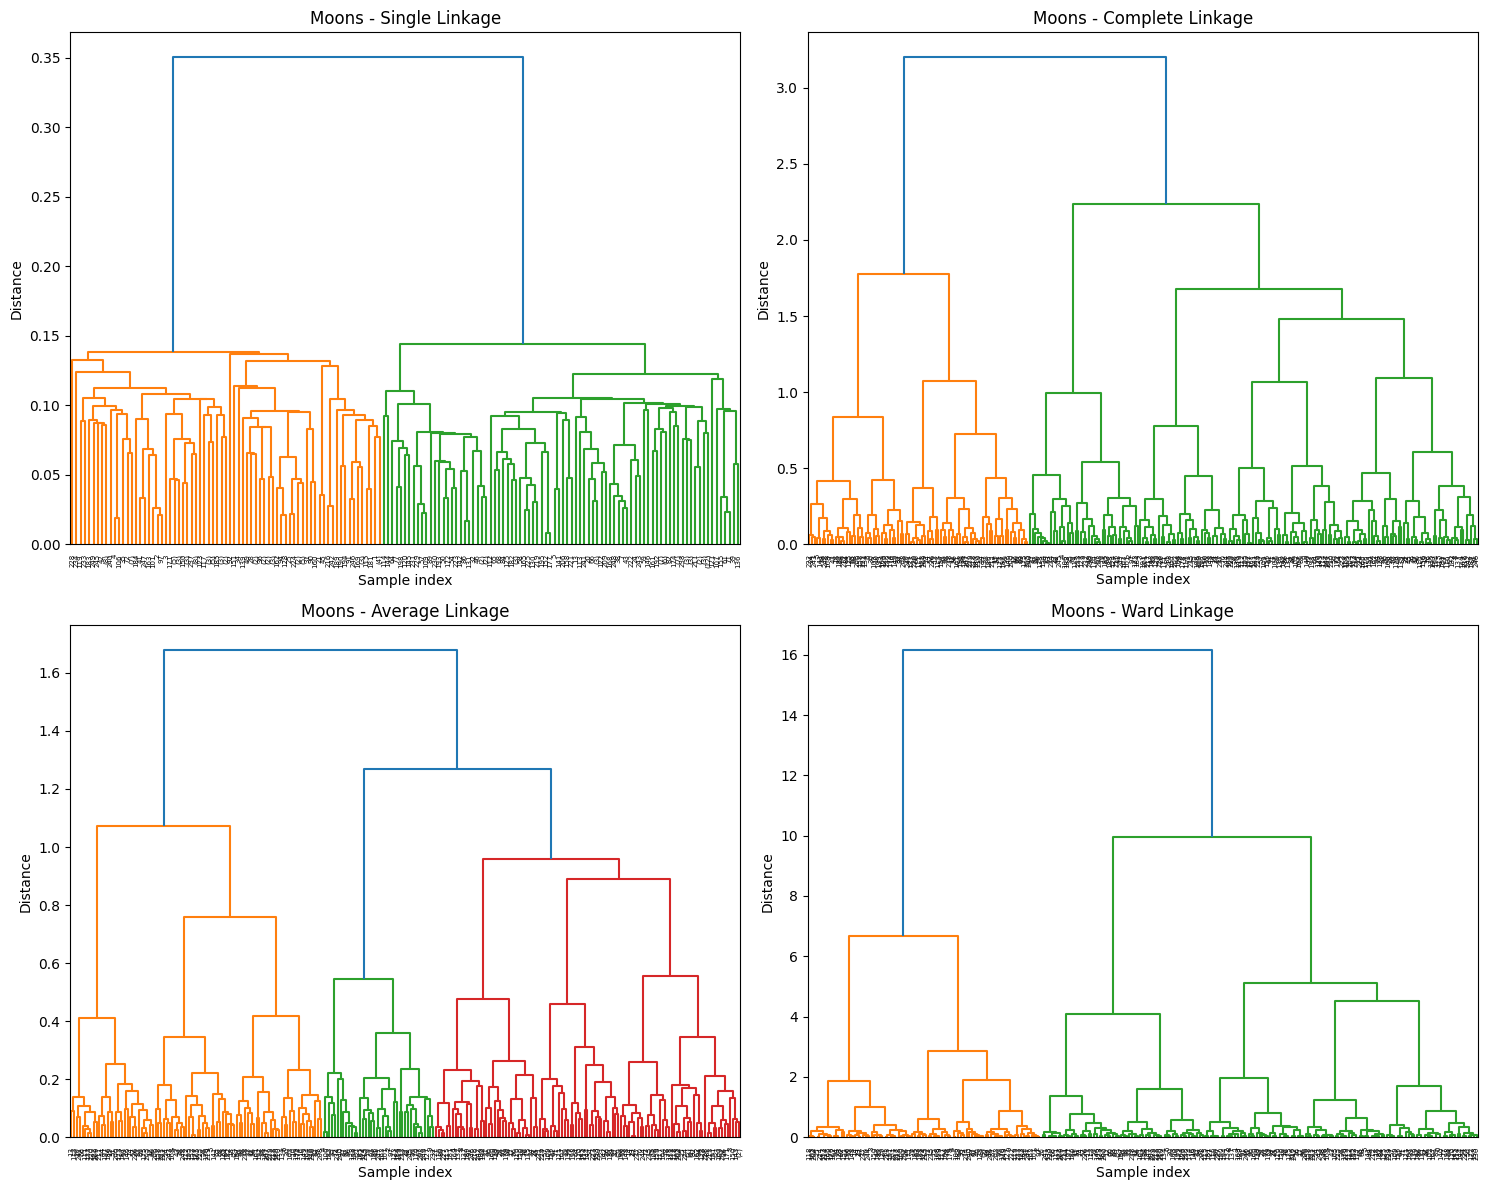

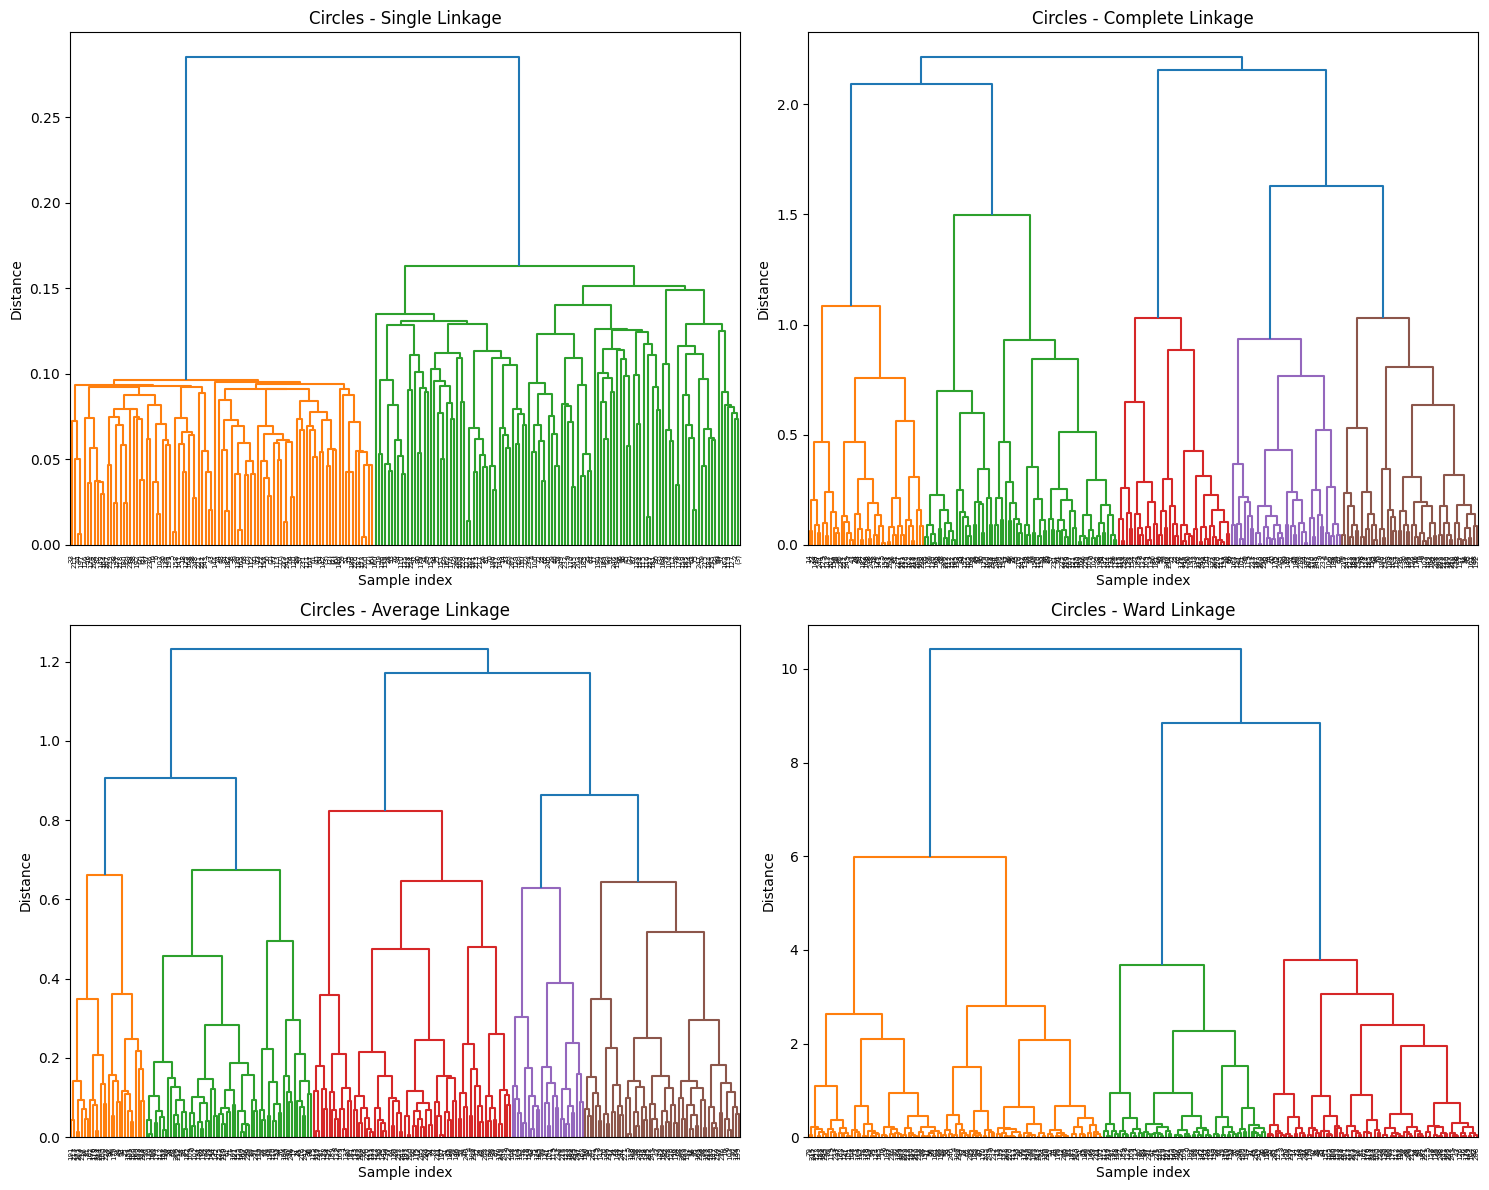

In [3]:
def plot_dendrograms(X, dataset_name):
    linkage_types = ['single', 'complete', 'average', 'ward']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, linkage_type in enumerate(linkage_types):
        
        if linkage_type == 'ward':
            Z = linkage(X, method=linkage_type, metric='euclidean')
        else:
            Z = linkage(X, method=linkage_type)
        
        axes[i].set_title(f"{dataset_name} - {linkage_type.capitalize()} Linkage")
        dendrogram(Z, ax=axes[i], truncate_mode='level', p=10)
        axes[i].set_xlabel("Sample index")
        axes[i].set_ylabel("Distance")
    
    plt.tight_layout()
    plt.show()

for name, (X, y) in datasets.items():
    plot_dendrograms(X, name)

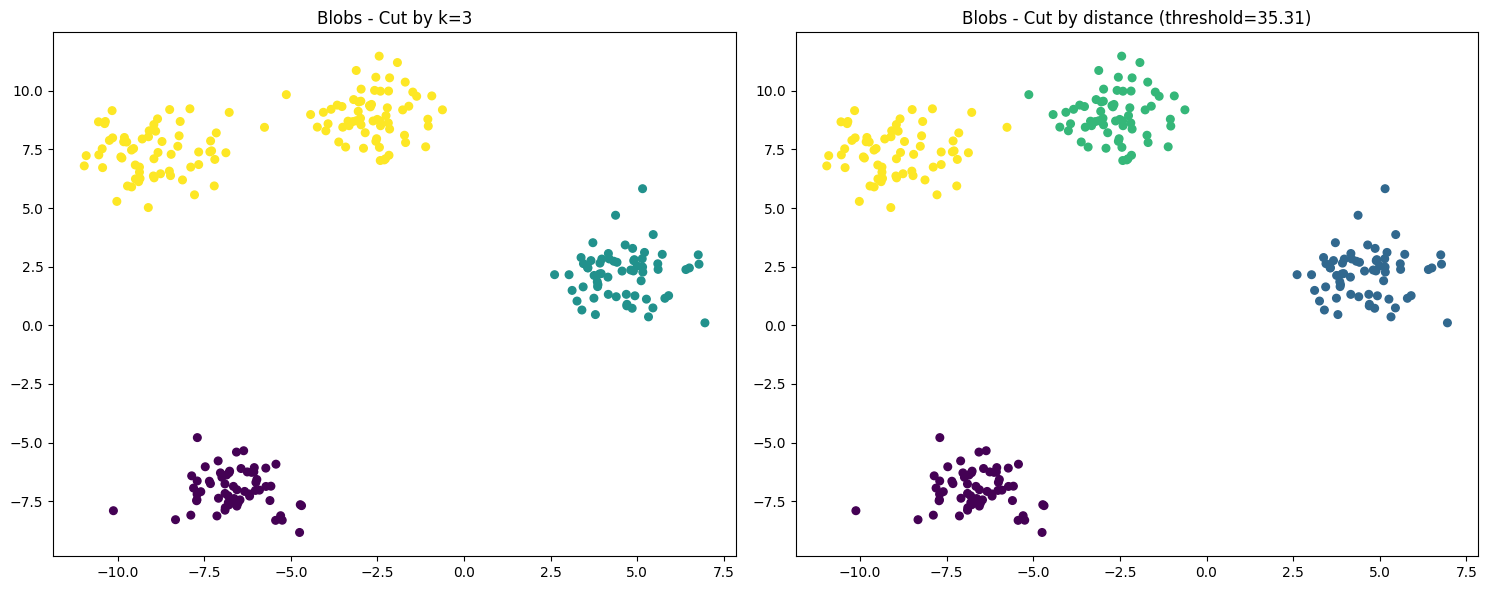

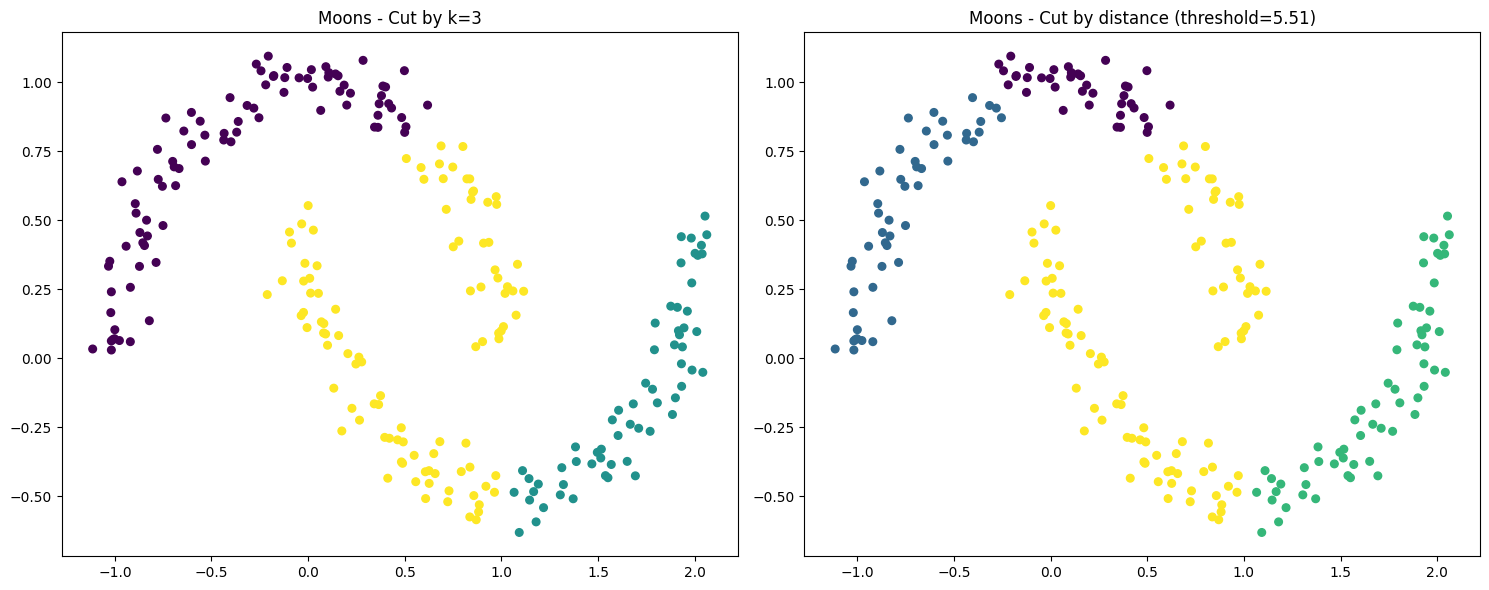

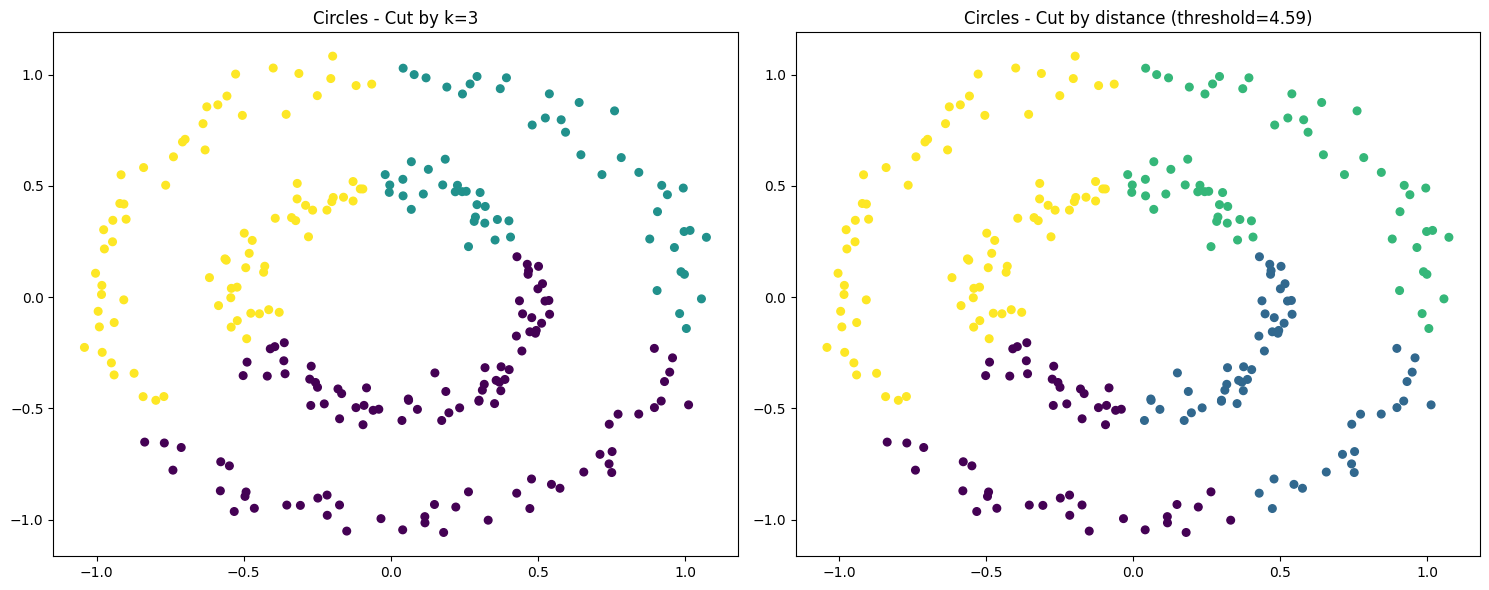

In [4]:
def cut_dendrogram_demo(X, dataset_name):
    Z = linkage(X, method='ward')
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    clusters_k3 = fcluster(Z, t=3, criterion='maxclust')

    max_dist = Z[-10:, 2].mean()  # Use average of last 10 merges as reference
    clusters_dist = fcluster(Z, t=max_dist, criterion='distance')

    axes[0].scatter(X[:, 0], X[:, 1], c=clusters_k3, cmap='viridis', s=30)
    axes[0].set_title(f"{dataset_name} - Cut by k=3")
    
    axes[1].scatter(X[:, 0], X[:, 1], c=clusters_dist, cmap='viridis', s=30)
    axes[1].set_title(f"{dataset_name} - Cut by distance (threshold={max_dist:.2f})")
    
    plt.tight_layout()
    plt.show()

for name, (X, y) in datasets.items():
    cut_dendrogram_demo(X, name)

In [5]:
def sklearn_agglomerative(X, y_true, dataset_name):
    linkage_types = ['single', 'complete', 'average', 'ward']
    results = []
    
    for linkage_type in linkage_types:

        model = AgglomerativeClustering(n_clusters=4, linkage=linkage_type)
        labels = model.fit_predict(X)

        if len(set(labels)) > 1:
            sil_score = silhouette_score(X, labels)
        else:
            sil_score = -1
        
        ari_score = adjusted_rand_score(y_true, labels)
        results.append({
            'Dataset': dataset_name,
            'Linkage': linkage_type,
            'Silhouette': round(sil_score, 4),
            'ARI': round(ari_score, 4),
            'Clusters': len(set(labels))
        })
    
    return pd.DataFrame(results)

all_results = []
for name, (X, y) in datasets.items():
    X_scaled = StandardScaler().fit_transform(X)
    results_df = sklearn_agglomerative(X_scaled, y, name)
    all_results.append(results_df)

summary_df = pd.concat(all_results, ignore_index=True)
print(summary_df.to_string())

    Dataset   Linkage  Silhouette     ARI  Clusters
0     Blobs    single      0.6709  0.7067         4
1     Blobs  complete      0.7907  0.9788         4
2     Blobs   average      0.7907  0.9788         4
3     Blobs      ward      0.7895  0.9893         4
4     Moons    single      0.2299  0.6947         4
5     Moons  complete      0.3894  0.1975         4
6     Moons   average      0.3604  0.3550         4
7     Moons      ward      0.4038  0.3924         4
8   Circles    single      0.2060  0.6758         4
9   Circles  complete      0.3217  0.0004         4
10  Circles   average      0.3393  0.0297         4
11  Circles      ward      0.3469  0.0116         4


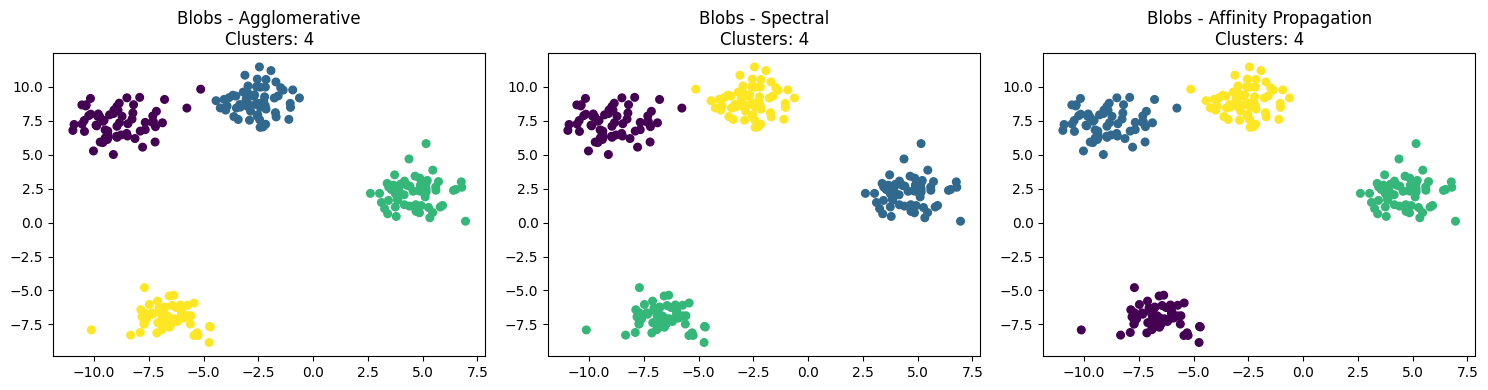

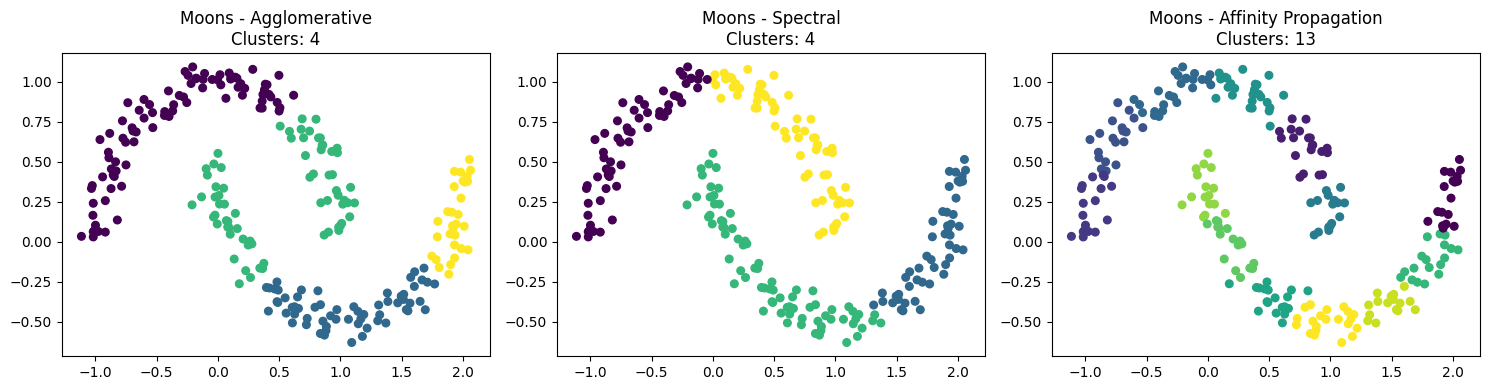

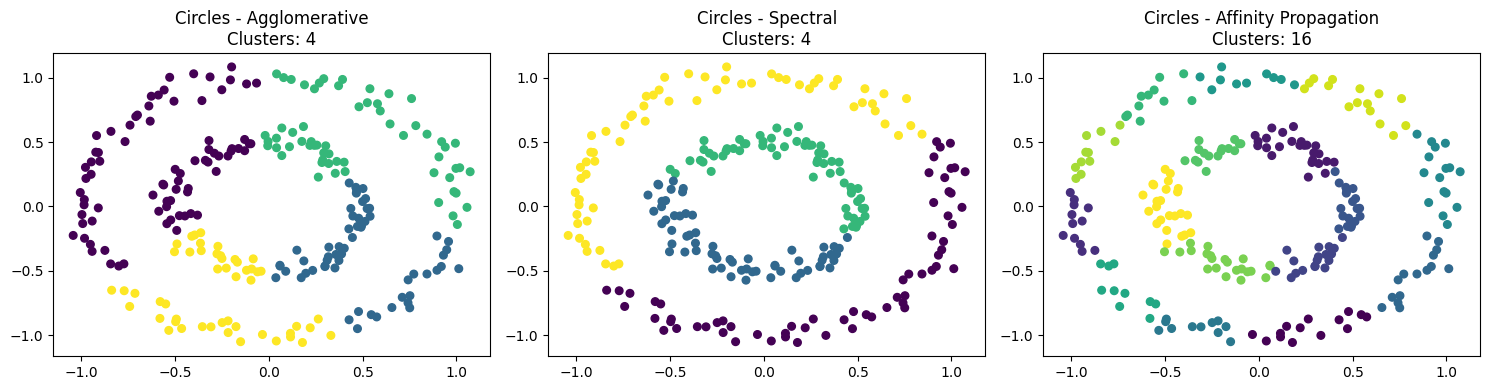

   Dataset         Method  Clusters Found  Silhouette     ARI
0    Blobs  Agglomerative               4      0.7895  0.9893
1    Blobs       Spectral               4      0.7935  1.0000
2    Blobs  Affinity Prop               4      0.7935  1.0000
3    Moons  Agglomerative               4      0.4038  0.3924
4    Moons       Spectral               4      0.3816  0.5091
5    Moons  Affinity Prop              13      0.4622  0.1515
6  Circles  Agglomerative               4      0.3469  0.0116
7  Circles       Spectral               4      0.1645  0.4970
8  Circles  Affinity Prop              16      0.4773  0.1302


In [6]:
def compare_clustering_methods(X, y_true, dataset_name):
    
    X_scaled = StandardScaler().fit_transform(X)
    results = []

    agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
    labels_agg = agg.fit_predict(X_scaled)

    spec = SpectralClustering(n_clusters=4, random_state=42, affinity='nearest_neighbors')
    labels_spec = spec.fit_predict(X_scaled)

    ap = AffinityPropagation(random_state=42)
    labels_ap = ap.fit_predict(X_scaled)

    for name, labels in [('Agglomerative', labels_agg), 
                          ('Spectral', labels_spec), 
                          ('Affinity Prop', labels_ap)]:
        n_clusters = len(set(labels))
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1
        ari = adjusted_rand_score(y_true, labels)
        
        results.append({
            'Dataset': dataset_name,
            'Method': name,
            'Clusters Found': n_clusters,
            'Silhouette': round(sil, 4),
            'ARI': round(ari, 4)
        })

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    all_labels = [labels_agg, labels_spec, labels_ap]
    titles = ['Agglomerative', 'Spectral', 'Affinity Propagation']
    
    for ax, labels, title in zip(axes, all_labels, titles):
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
        ax.set_title(f"{dataset_name} - {title}\nClusters: {len(set(labels))}")
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

comparison_results = []
for name, (X, y) in datasets.items():
    comp_df = compare_clustering_methods(X, y, name)
    comparison_results.append(comp_df)

comparison_summary = pd.concat(comparison_results, ignore_index=True)
print(comparison_summary.to_string())


Blobs:


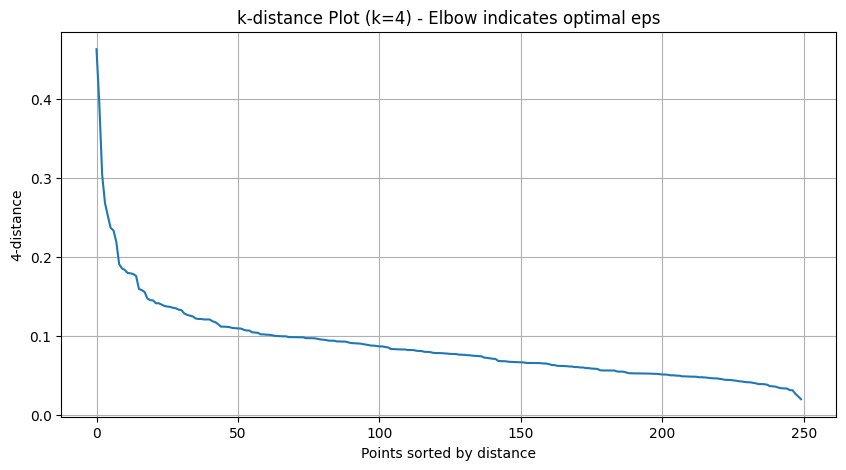

Recommended eps range: 0.10 - 0.14

Moons:


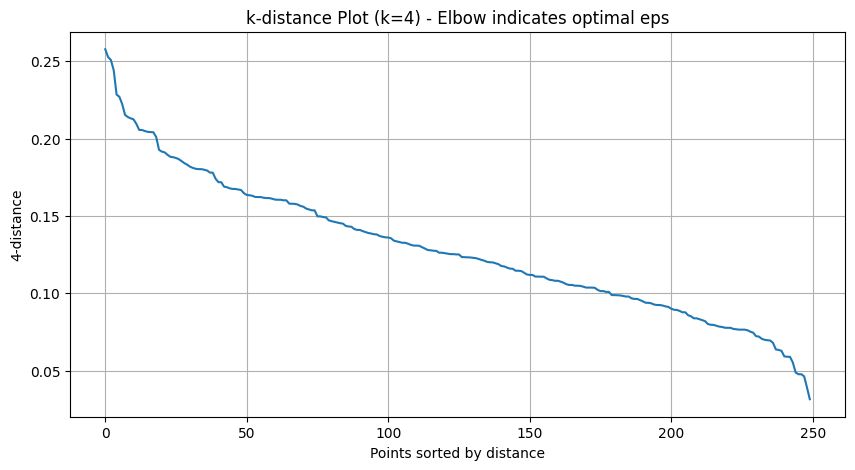

Recommended eps range: 0.16 - 0.19

Circles:


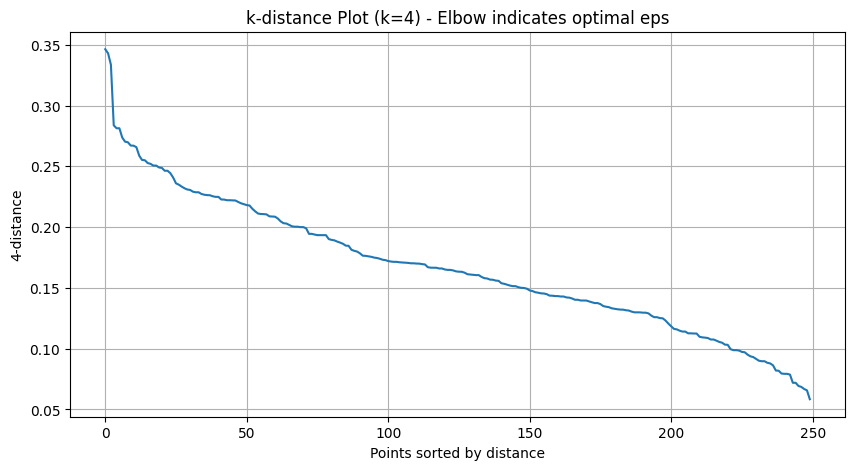

Recommended eps range: 0.20 - 0.24


In [7]:
def plot_k_distance(X, k=4):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, indices = neigh.kneighbors(X)
    k_distances = np.sort(distances[:, k-1])[::-1]
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(k_distances)), k_distances)
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-distance')
    plt.title(f'k-distance Plot (k={k}) - Elbow indicates optimal eps')
    plt.grid(True)
    plt.show()
    
    return k_distances

for name, (X, y) in datasets.items():
    X_scaled = StandardScaler().fit_transform(X)
    print(f"\n{name}:")
    k_dist = plot_k_distance(X_scaled, k=4)
    print(f"Recommended eps range: {k_dist[len(k_dist)//4]:.2f} - {k_dist[len(k_dist)//10]:.2f}")

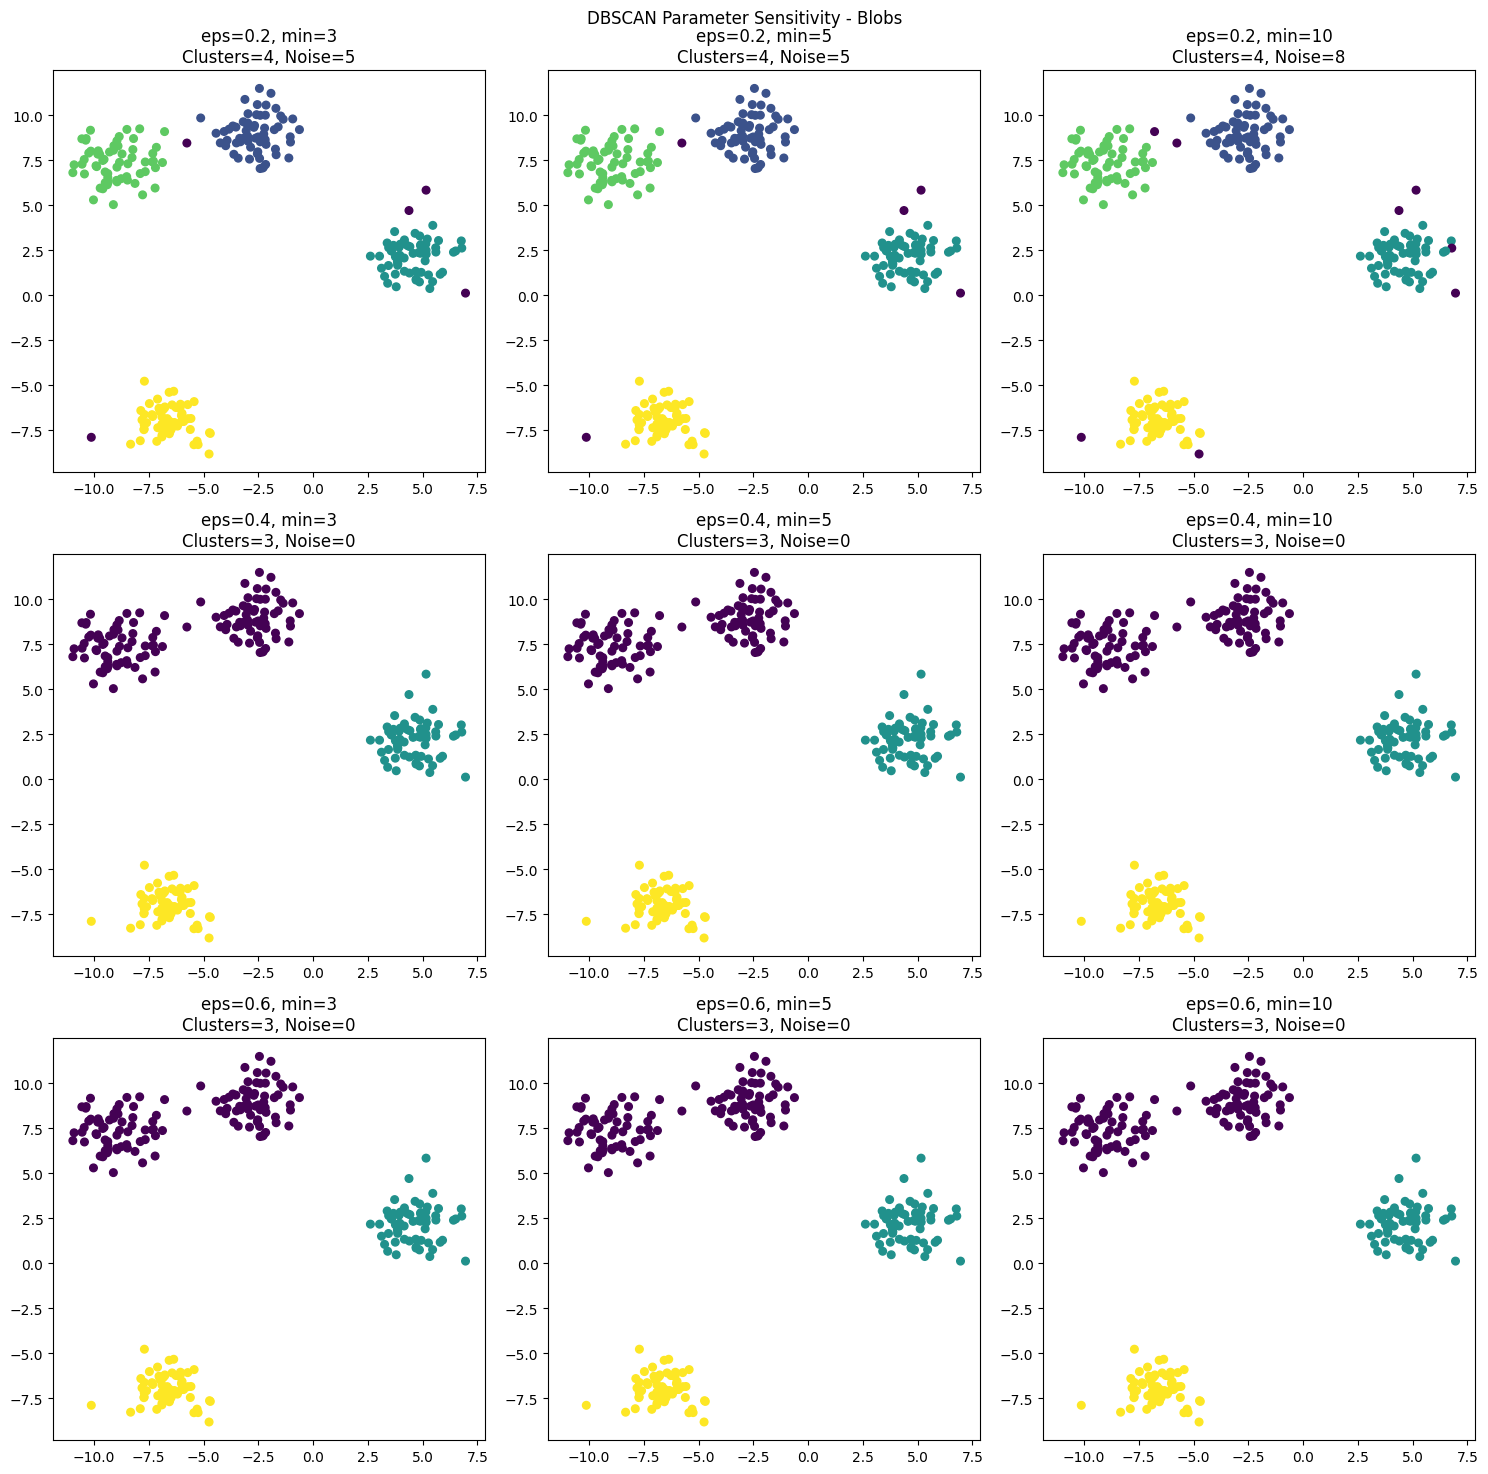

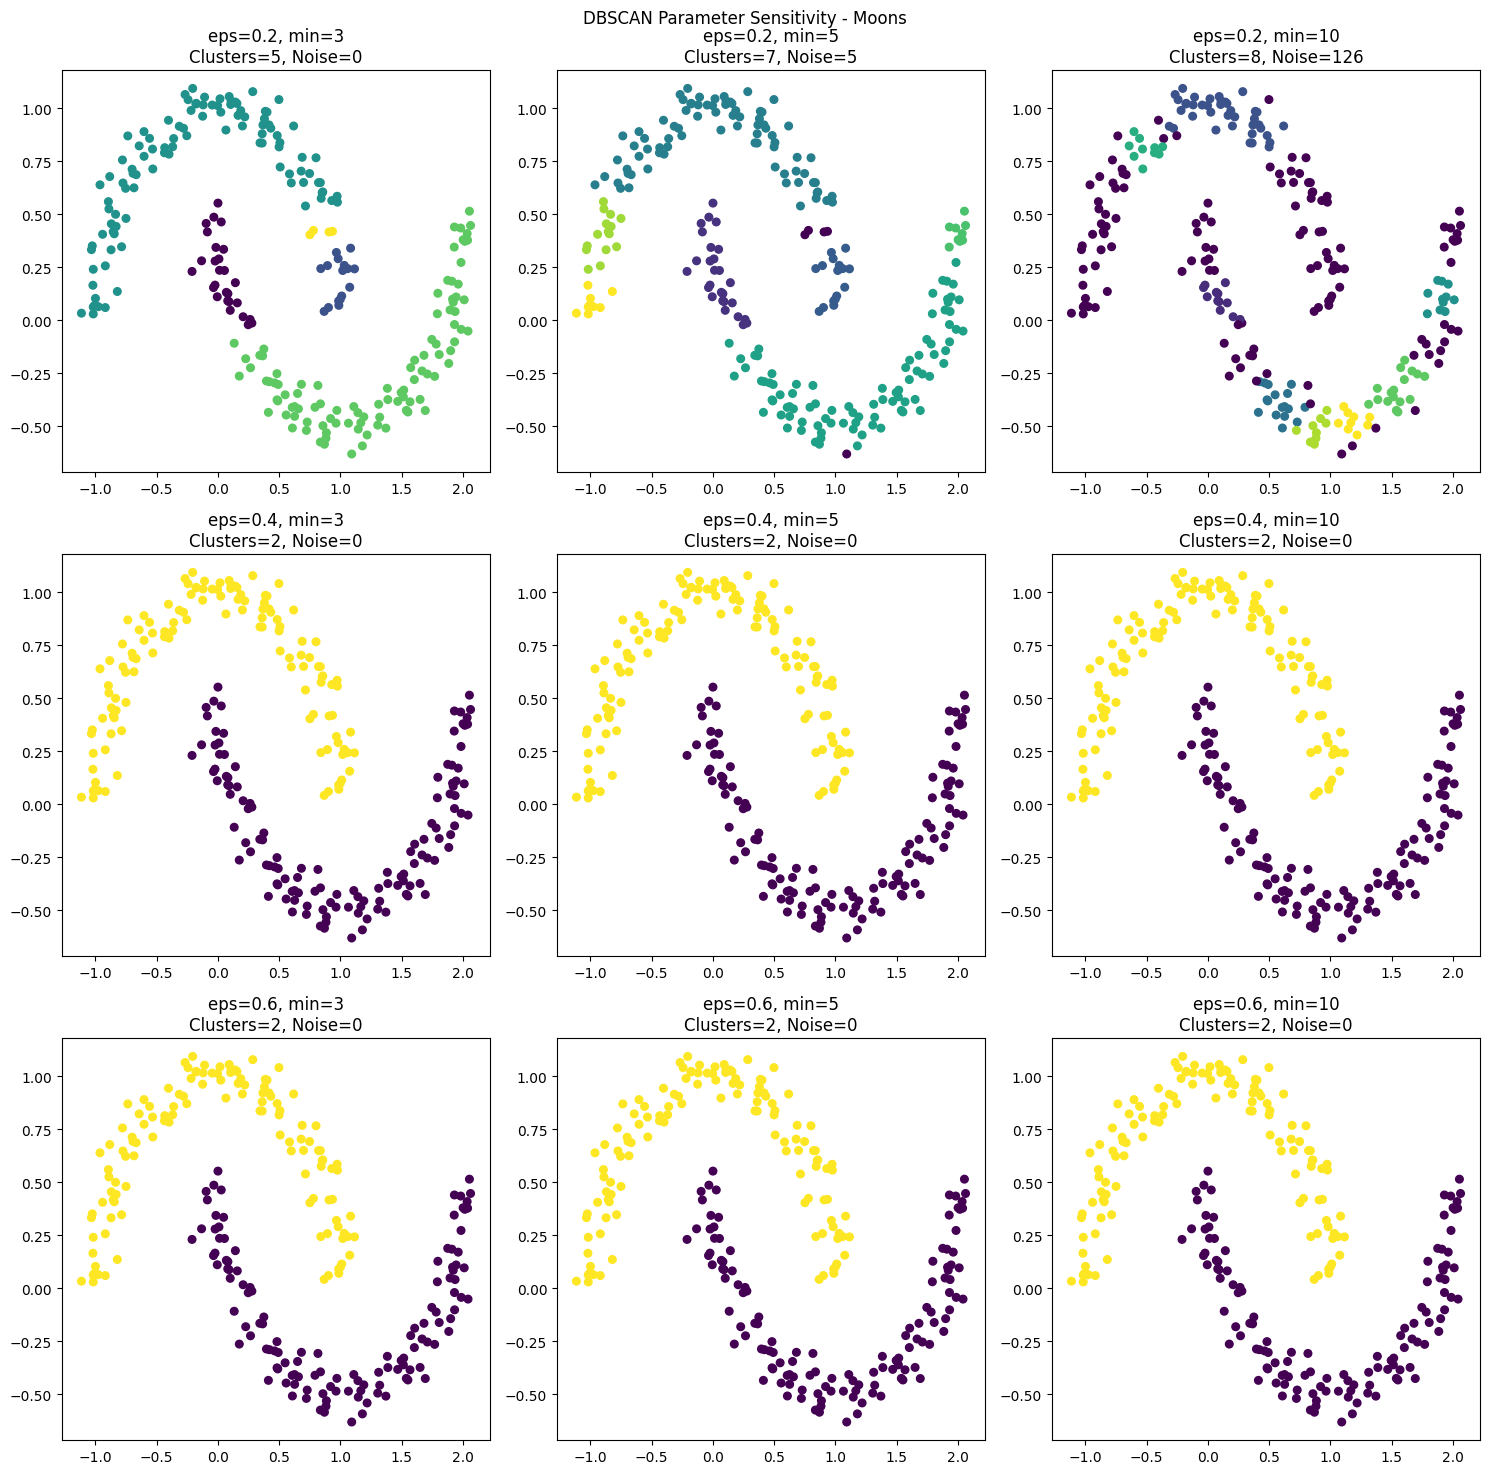

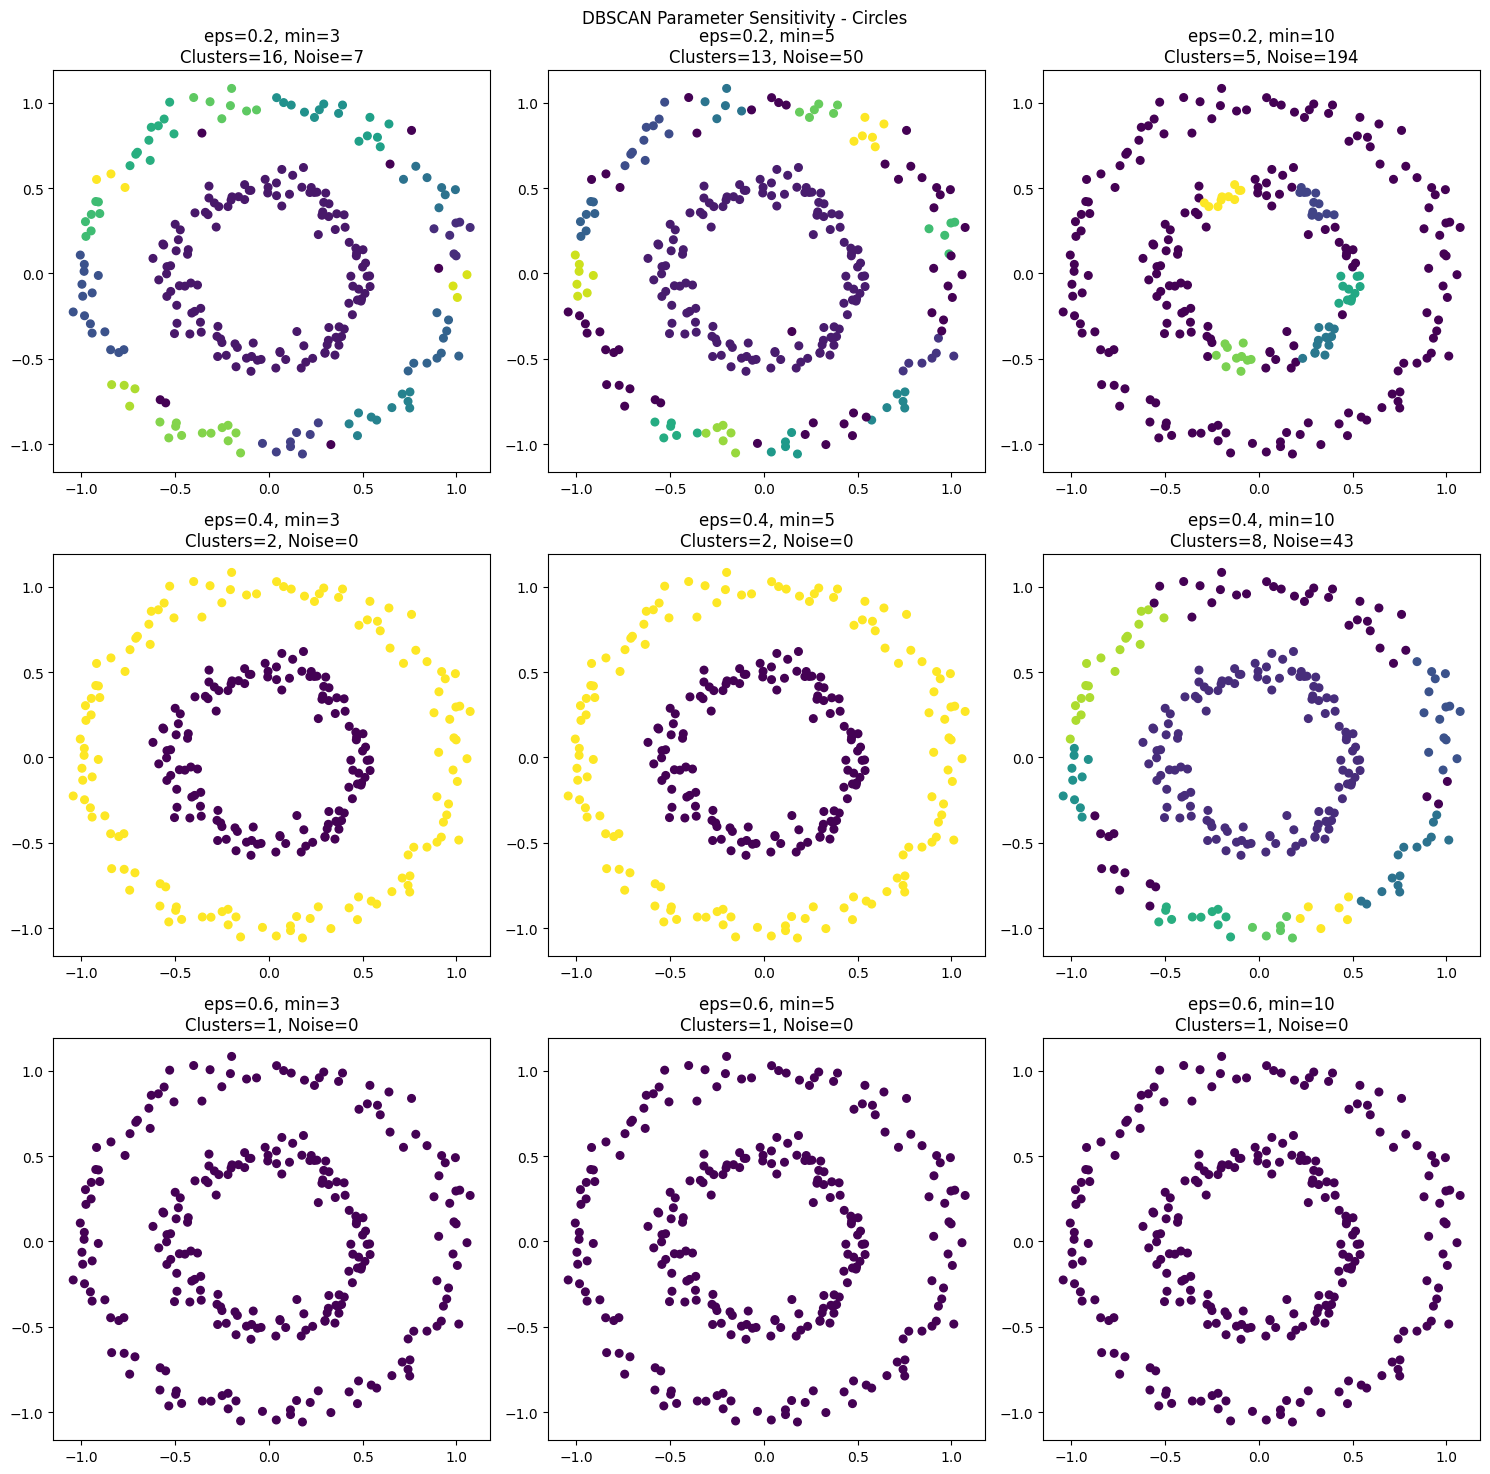

    Dataset  eps  min_samples  Clusters  Noise Points  Silhouette
0     Blobs  0.2            3         4             5      0.7628
1     Blobs  0.2            5         4             5      0.7628
2     Blobs  0.2           10         4             8      0.7512
3     Blobs  0.4            3         3             0      0.7407
4     Blobs  0.4            5         3             0      0.7407
5     Blobs  0.4           10         3             0      0.7407
6     Blobs  0.6            3         3             0      0.7407
7     Blobs  0.6            5         3             0      0.7407
8     Blobs  0.6           10         3             0      0.7407
9     Moons  0.2            3         5             0      0.1589
10    Moons  0.2            5         7             5      0.3107
11    Moons  0.2           10         8           126      0.0087
12    Moons  0.4            3         2             0      0.3744
13    Moons  0.4            5         2             0      0.3744
14    Moon

In [8]:
def run_dbscan_combinations(X, y_true, dataset_name):
    X_scaled = StandardScaler().fit_transform(X)
    
    param_combinations = [
        (0.2, 3), (0.2, 5), (0.2, 10),
        (0.4, 3), (0.4, 5), (0.4, 10),
        (0.6, 3), (0.6, 5), (0.6, 10)
    ]
    
    results = []
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel()
    
    for idx, (eps, min_samples) in enumerate(param_combinations):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = -1
        
        results.append({
            'Dataset': dataset_name,
            'eps': eps,
            'min_samples': min_samples,
            'Clusters': n_clusters,
            'Noise Points': n_noise,
            'Silhouette': round(sil, 4)
        })

        axes[idx].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
        axes[idx].set_title(f'eps={eps}, min={min_samples}\nClusters={n_clusters}, Noise={n_noise}')
    
    plt.suptitle(f'DBSCAN Parameter Sensitivity - {dataset_name}')
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

dbscan_results = []
for name, (X, y) in datasets.items():
    db_df = run_dbscan_combinations(X, y, name)
    dbscan_results.append(db_df)

dbscan_summary = pd.concat(dbscan_results, ignore_index=True)
print(dbscan_summary.to_string())

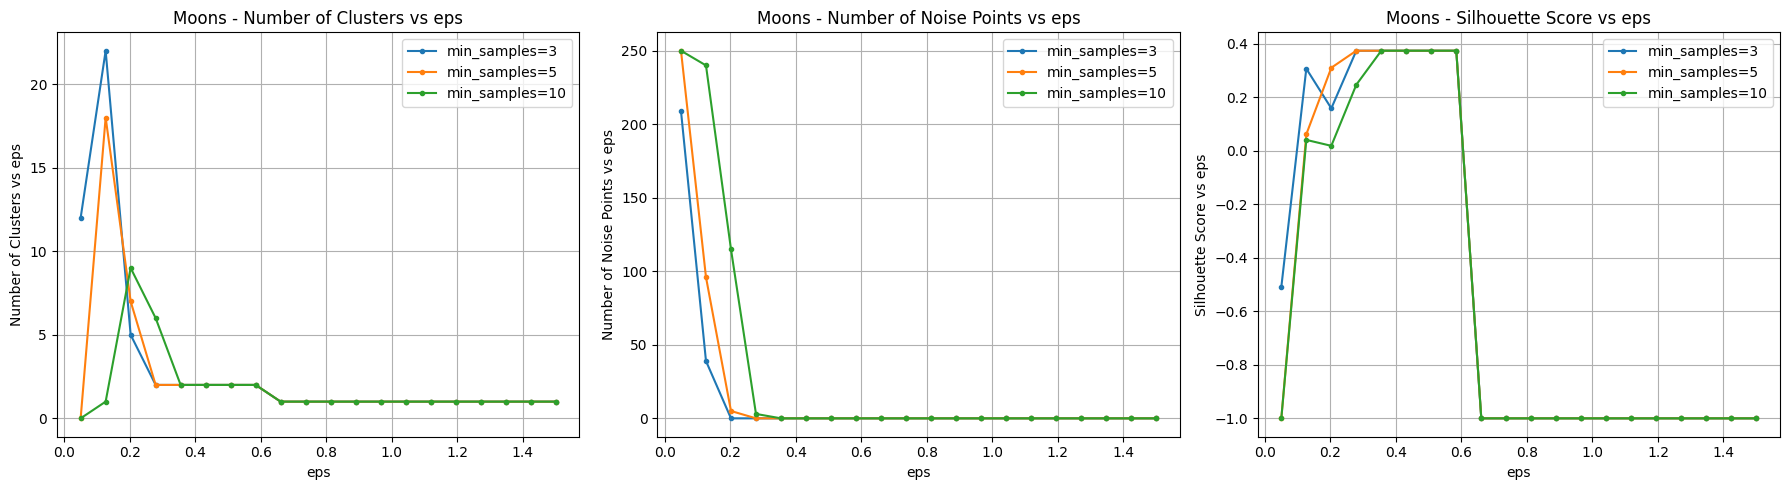

In [9]:
def parameter_sensitivity_analysis(X, dataset_name):
    X_scaled = StandardScaler().fit_transform(X)
    
    eps_values = np.linspace(0.05, 1.5, 20)
    min_samples_values = [3, 5, 10]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metrics = ['clusters', 'noise', 'silhouette']
    titles = ['Number of Clusters vs eps', 'Number of Noise Points vs eps', 'Silhouette Score vs eps']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        for min_s in min_samples_values:
            values = []
            for eps in eps_values:
                db = DBSCAN(eps=eps, min_samples=min_s)
                labels = db.fit_predict(X_scaled)
                
                if metric == 'clusters':
                    val = len(set(labels)) - (1 if -1 in labels else 0)
                elif metric == 'noise':
                    val = np.sum(labels == -1)
                else:
                    if len(set(labels)) > 1 and len(set(labels)) < len(X_scaled):
                        val = silhouette_score(X_scaled, labels)
                    else:
                        val = -1
                values.append(val)
            
            axes[i].plot(eps_values, values, label=f'min_samples={min_s}', marker='o', markersize=3)
        
        axes[i].set_xlabel('eps')
        axes[i].set_ylabel(title)
        axes[i].set_title(f'{dataset_name} - {title}')
        axes[i].legend()
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()

X_moons, y_moons = datasets['Moons']
parameter_sensitivity_analysis(X_moons, 'Moons')